In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
np.random.seed(0)
data = pd.DataFrame({
    'TV': np.random.uniform(0, 100, 100),
    'Radio': np.random.uniform(0, 50, 100),
    'Sales': np.random.uniform(0, 30, 100)
})

In [3]:
data['Sales_High'] = np.where(data['Sales'] > data['Sales'].median(), 1, 0)


In [4]:
X = data[['TV', 'Radio']]
y = data['Sales_High']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [5]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [6]:
y_pred = model.predict(X_test)

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.4666666666666667
Confusion Matrix:
 [[6 9]
 [7 8]]


<Axes: xlabel='TV', ylabel='Radio'>

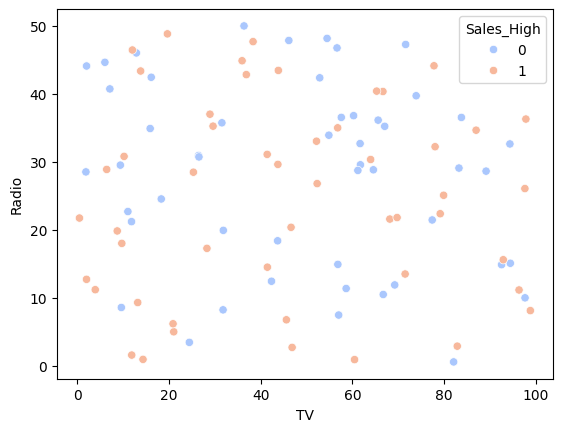

In [8]:
sns.scatterplot(x='TV', y='Radio', hue='Sales_High', data=data, palette='coolwarm')


/home/lakshya/jupyter/paper/DFU/Patches/dfu/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


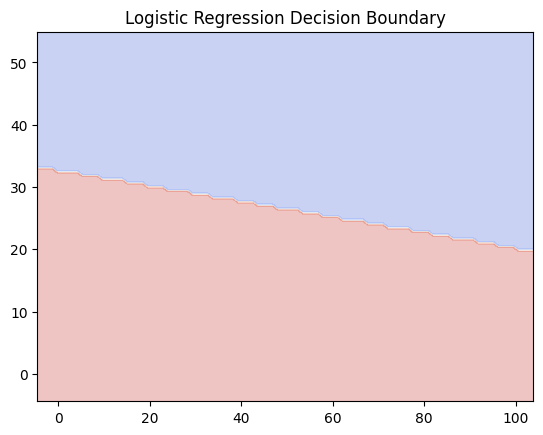

In [13]:
x_min, x_max = X['TV'].min() - 5, X['TV'].max() + 5
y_min, y_max = X['Radio'].min() - 5, X['Radio'].max() + 5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.title("Logistic Regression Decision Boundary")
plt.show()